In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import warnings
warnings.filterwarnings("ignore")

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

# Check versions
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

# Download the dataset
path = kagglehub.dataset_download("bmshahriaalam/tealeafbd-tea-leaf-disease-detection")
print("Path to dataset files:", path)

# Check available folders (classes)
classes = os.listdir(path + "/teaLeafBD/teaLeafBD")
print("Classes in dataset:", classes)

Path to dataset files: /kaggle/input/tealeafbd-tea-leaf-disease-detection
Classes in dataset: ['3. Gray Blight', '2. Brown Blight', '7. Healthy leaf', '6. Green mirid bug', '1. Tea algal leaf spot', '4. Helopeltis', '5. Red spider']


In [ ]:
# Count number of images per class
class_counts = {}
for c in classes:
    class_path = os.path.join(path, "teaLeafBD/teaLeafBD", c)
    class_counts[c] = len(os.listdir(class_path))

In [ ]:
# Convert to DataFrame for overview
import pandas as pd
df_overview = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image Count"])
print(df_overview)

                    Class  Image Count
0          3. Gray Blight         1013
1         2. Brown Blight          506
2         7. Healthy leaf          935
3      6. Green mirid bug         1282
4  1. Tea algal leaf spot          418
5           4. Helopeltis          607
6           5. Red spider          515


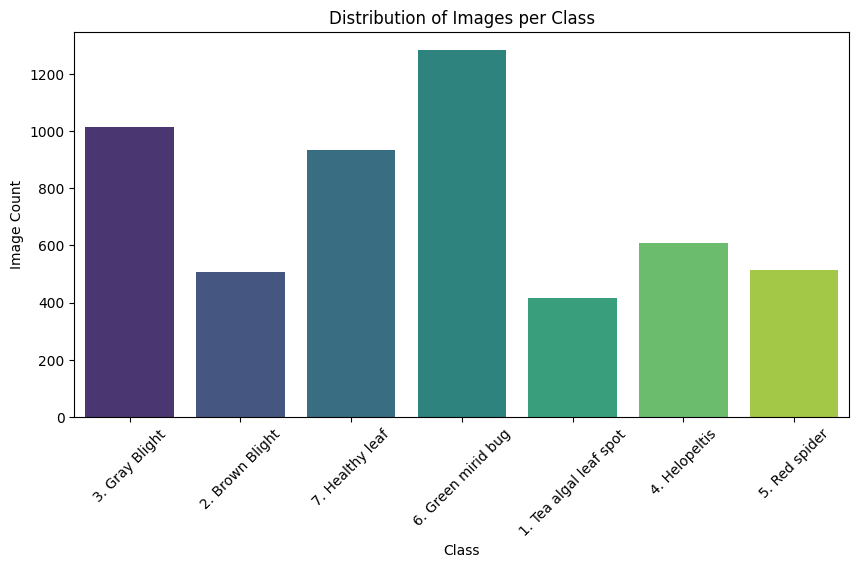

In [ ]:
# Plot class distribution
plt.figure(figsize=(10,5))
sns.barplot(x="Class", y="Image Count", data=df_overview, palette="viridis")
plt.xticks(rotation=45)
plt.title("Distribution of Images per Class")
plt.show()

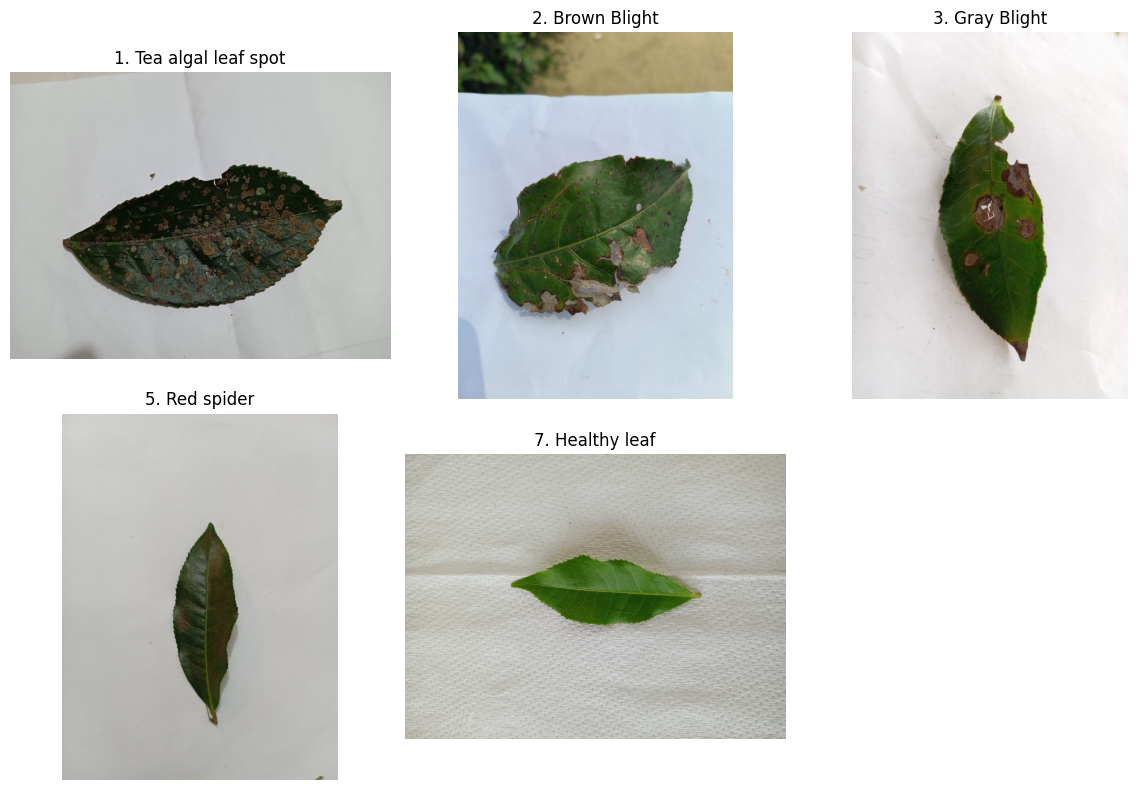

In [ ]:
# Show random sample images from 5 classes
selected_classes = ["1. Tea algal leaf spot", "2. Brown Blight", "3. Gray Blight",
                    "5. Red spider", "7. Healthy leaf"]

plt.figure(figsize=(12, 8))
for i, c in enumerate(selected_classes):
    class_path = os.path.join(path, "teaLeafBD/teaLeafBD", c)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import shutil
from sklearn.model_selection import train_test_split

# Define selected classes
selected_classes = ["1. Tea algal leaf spot", "2. Brown Blight", "3. Gray Blight",
                    "5. Red spider", "7. Healthy leaf"]

# Parameters
IMG_SIZE = 224
SAMPLES_PER_CLASS = 400

# Create dataset arrays
X, y = [], []

label_map = {c: i for i, c in enumerate(selected_classes)}  # map class names to numbers

for c in selected_classes:
    class_path = os.path.join(path, "teaLeafBD/teaLeafBD", c)
    img_files = os.listdir(class_path)

    # Randomly choose 400 images per class
    img_files = random.sample(img_files, SAMPLES_PER_CLASS)

    for img_name in img_files:
        img_path = os.path.join(class_path, img_name)

        # Read and preprocess
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0  # Normalize (0-1)

        X.append(img)
        y.append(label_map[c])

# Convert to numpy arrays
X = np.array(X, dtype="float32")
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)

Dataset shape: (2000, 224, 224, 3) (2000,)


In [ ]:
# Train-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1400, 224, 224, 3)
Validation set: (300, 224, 224, 3)
Test set: (300, 224, 224, 3)


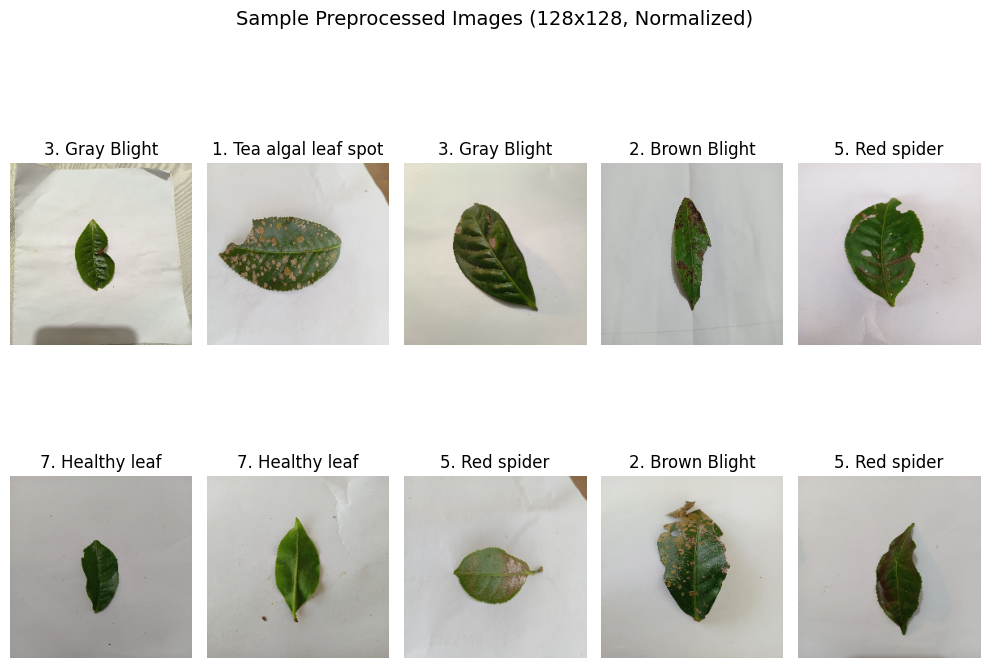

In [ ]:
# Show sample preprocessed images
plt.figure(figsize=(10, 8))
for i in range(10):
    idx = random.randint(0, len(X) - 1)
    plt.subplot(2, 5, i+1)
    plt.imshow(X[idx])   # already normalized (0–1)
    plt.title(list(label_map.keys())[list(label_map.values()).index(y[idx])])
    plt.axis("off")
plt.suptitle("Sample Preprocessed Images (128x128, Normalized)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Parameters
img_height, img_width = 224, 224
NUM_CLASSES = len(selected_classes)  # = 5

# Load base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # freeze pretrained layers

# Build model
inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # GAP instead of Flatten
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
model = tf.keras.Model(inputs, outputs)

# Compile
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

In [ ]:
# Train model with callbacks
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,   # give enough room for early stopping
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7347 - loss: 0.6743 - val_accuracy: 0.7533 - val_loss: 0.6602 - learning_rate: 5.0000e-05
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7314 - loss: 0.6858 - val_accuracy: 0.7533 - val_loss: 0.6598 - learning_rate: 5.0000e-05
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.7429 - loss: 0.6650 - val_accuracy: 0.7467 - val_loss: 0.6558 - learning_rate: 5.0000e-05
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7618 - loss: 0.6452 - val_accuracy: 0.7600 - val_loss: 0.6587 - learning_rate: 5.0000e-05
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7727 - loss: 0.6086 - val_accuracy: 0.7600 - val_loss: 0.6546 - learning_rate: 5.0000e-05
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7557 - loss: 0.6322 - val_accuracy: 0.7600 - val_loss: 0.6529 - learning_rate: 5.0000e-05
Epoch 7/30
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7687 -

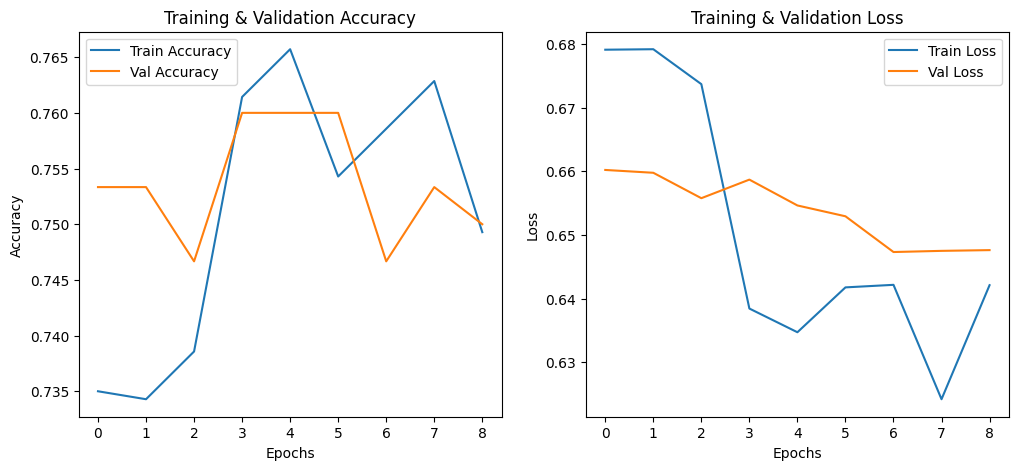

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")

plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 959ms/step


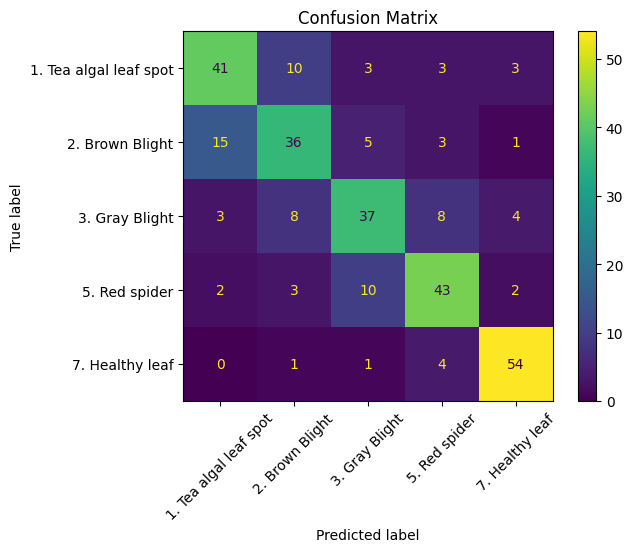

                        precision    recall  f1-score   support

1. Tea algal leaf spot       0.67      0.68      0.68        60
       2. Brown Blight       0.62      0.60      0.61        60
        3. Gray Blight       0.66      0.62      0.64        60
         5. Red spider       0.70      0.72      0.71        60
       7. Healthy leaf       0.84      0.90      0.87        60

              accuracy                           0.70       300
             macro avg       0.70      0.70      0.70       300
          weighted avg       0.70      0.70      0.70       300



In [ ]:
# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=selected_classes)
disp.plot(cmap="viridis", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_classes, target_names=selected_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


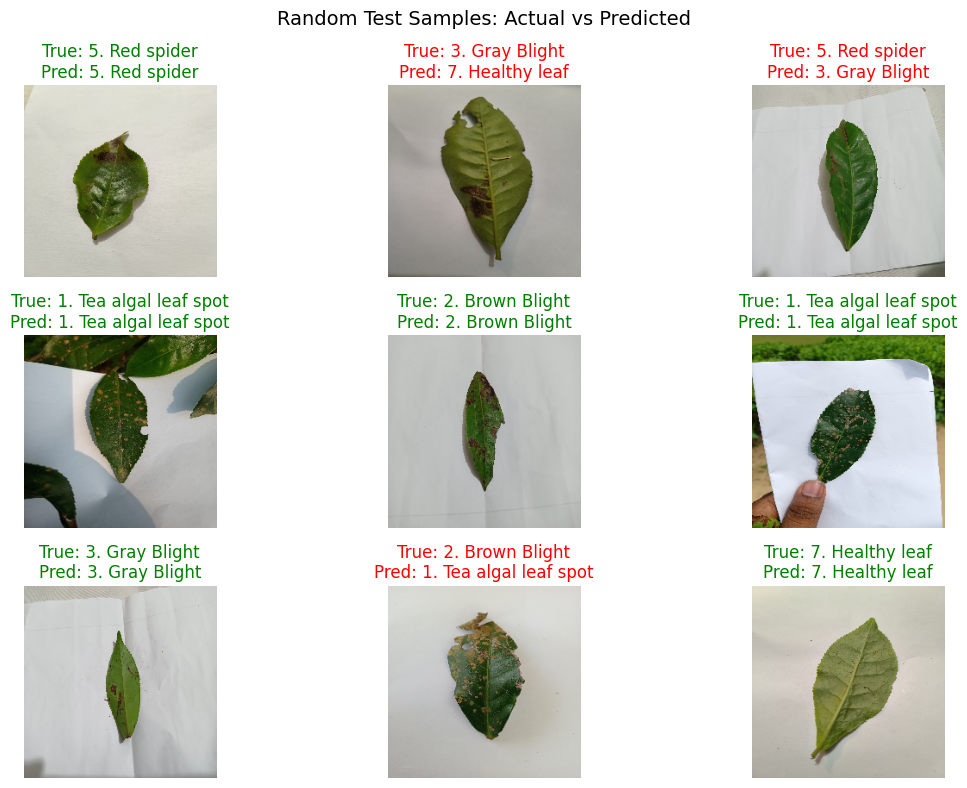

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(9):
    idx = random.randint(0, len(X_test)-1)
    img = X_test[idx]
    true_label = selected_classes[y_test[idx]]

    pred = model.predict(np.expand_dims(img, axis=0))
    pred_label = selected_classes[np.argmax(pred)]

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}",
              color=("green" if true_label==pred_label else "red"))
    plt.axis("off")
plt.suptitle("Random Test Samples: Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()